In [1]:
"""
NGO Report Scraper
==================
Searches public NGO databases and report repositories for reports
mentioning Tesla, Volkswagen, Disney, or Netflix, then downloads them.

Sources searched:
  - Business & Human Rights Resource Centre (BHRRC)
  - Corporate Watch
  - ShareAction
  - Global Witness
  - OpenCorporates (basic public API)

Usage:
    scraper = Scraper("Tesla", 2023, number_of_close_matches=5)
    scraper.scrape()

    # Or bulk-run:
    for company in COMPANIES:
        for year in YEARS:
            Scraper(company, year, number_of_close_matches=5).scrape()
"""

import os
import re
import time
import difflib
import logging
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import requests
from bs4 import BeautifulSoup

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

COMPANIES = ["Tesla", "Volkswagen", "Disney", "Netflix"]
YEARS     = [2022, 2023, 2024]

OUTPUT_DIR = Path("ngo_reports")   # reports saved here; one sub-folder per company

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; NGO-Report-Scraper/1.0; "
        "+https://github.com/your-org/ngo-scraper)"
    )
}

REQUEST_DELAY = 1.5   # seconds between requests — be polite

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)


# ---------------------------------------------------------------------------
# Data model for a single found report
# ---------------------------------------------------------------------------

@dataclass
class Report:
    title:      str
    url:        str
    source:     str
    year:       Optional[int] = None
    match_score: float = 0.0    # 0–1 similarity to the company name
    local_path: Optional[Path] = None


# ---------------------------------------------------------------------------
# Source adapters
# ---------------------------------------------------------------------------

class _BHRRCAdapter:
    """
    Business & Human Rights Resource Centre — https://www.business-humanrights.org
    Searches their public search page for the company name.
    """
    name = "BHRRC"
    base = "https://www.business-humanrights.org"

    def search(self, company: str, year: int) -> list[dict]:
        results = []
        url = (
            f"{self.base}/en/search/?q={requests.utils.quote(company)}"
            f"&type=report&date_from={year}-01-01&date_to={year}-12-31"
        )
        try:
            r = requests.get(url, headers=HEADERS, timeout=15)
            r.raise_for_status()
        except requests.RequestException as exc:
            log.warning("BHRRC request failed: %s", exc)
            return results

        soup = BeautifulSoup(r.text, "html.parser")
        for item in soup.select("article.search-result, div.result-item, li.search-item"):
            a_tag = item.find("a", href=True)
            if not a_tag:
                continue
            href = a_tag["href"]
            if not href.startswith("http"):
                href = self.base + href
            results.append({"title": a_tag.get_text(strip=True), "url": href})
        return results


class _ShareActionAdapter:
    """
    ShareAction — https://shareaction.org
    Parses their /resources/ listing filtered by tag.
    """
    name = "ShareAction"
    base = "https://shareaction.org"

    def search(self, company: str, year: int) -> list[dict]:
        results = []
        url = f"{self.base}/resources/?search={requests.utils.quote(company)}&year={year}"
        try:
            r = requests.get(url, headers=HEADERS, timeout=15)
            r.raise_for_status()
        except requests.RequestException as exc:
            log.warning("ShareAction request failed: %s", exc)
            return results

        soup = BeautifulSoup(r.text, "html.parser")
        for card in soup.select("div.resource-card, article.resource, .post-card"):
            a_tag = card.find("a", href=True)
            if not a_tag:
                continue
            href = a_tag["href"]
            if not href.startswith("http"):
                href = self.base + href
            results.append({"title": a_tag.get_text(strip=True), "url": href})
        return results


class _GlobalWitnessAdapter:
    """
    Global Witness — https://www.globalwitness.org
    Searches their /reports/ archive page.
    """
    name = "GlobalWitness"
    base = "https://www.globalwitness.org"

    def search(self, company: str, year: int) -> list[dict]:
        results = []
        url = (
            f"{self.base}/en/reports/"
            f"?search={requests.utils.quote(company)}&year={year}"
        )
        try:
            r = requests.get(url, headers=HEADERS, timeout=15)
            r.raise_for_status()
        except requests.RequestException as exc:
            log.warning("GlobalWitness request failed: %s", exc)
            return results

        soup = BeautifulSoup(r.text, "html.parser")
        for item in soup.select("article, .report-item, .content-card"):
            a_tag = item.find("a", href=True)
            if not a_tag:
                continue
            href = a_tag["href"]
            if not href.startswith("http"):
                href = self.base + href
            results.append({"title": a_tag.get_text(strip=True), "url": href})
        return results


# Add more adapters here (e.g. CorpWatch, Amnesty, Oxfam…) following the same pattern.
ADAPTERS = [_BHRRCAdapter(), _ShareActionAdapter(), _GlobalWitnessAdapter()]


# ---------------------------------------------------------------------------
# Main Scraper class
# ---------------------------------------------------------------------------

class Scraper:
    """
    Scrapes NGO report repositories for reports about `company` in `year`.

    Parameters
    ----------
    company : str
        Company name to search for (e.g. "Tesla").
    year : int
        Publication year to filter results.
    number_of_close_matches : int
        How many fuzzy-matched results to keep per source (default 5).
    output_dir : Path | str
        Root folder where reports are saved. Defaults to OUTPUT_DIR.
    min_score : float
        Minimum fuzzy-match ratio (0–1) for a result to be kept.
    """

    def __init__(
        self,
        company: str,
        year: int,
        number_of_close_matches: int = 5,
        output_dir: Path | str = OUTPUT_DIR,
        min_score: float = 0.25,
    ):
        self.company  = company
        self.year     = year
        self.number_of_close_matches = number_of_close_matches
        self.output_dir = Path(output_dir) / company / str(year)
        self.min_score  = min_score

        self.reports: list[Report] = []         # populated by scrape()
        self.saved_paths: list[Path] = []       # files actually written

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def scrape(self) -> list[Report]:
        """
        Run all source adapters, fuzzy-match results, download files.
        Returns the list of Report objects that were saved.
        """
        self.output_dir.mkdir(parents=True, exist_ok=True)
        log.info("Searching for '%s' reports (%d)…", self.company, self.year)

        raw: list[dict] = []
        for adapter in ADAPTERS:
            log.info("  → querying %s", adapter.name)
            hits = adapter.search(self.company, self.year)
            for h in hits:
                h["source"] = adapter.name
            raw.extend(hits)
            time.sleep(REQUEST_DELAY)

        # Fuzzy-score each result against the company name
        candidates: list[Report] = []
        for item in raw:
            score = self._match_score(item["title"])
            if score >= self.min_score:
                candidates.append(Report(
                    title=item["title"],
                    url=item["url"],
                    source=item.get("source", "unknown"),
                    year=self.year,
                    match_score=score,
                ))

        # Keep best N by score
        candidates.sort(key=lambda r: r.match_score, reverse=True)
        self.reports = candidates[: self.number_of_close_matches]

        if not self.reports:
            log.warning(
                "No close matches for '%s' (%d) — try lowering min_score "
                "or increasing number_of_close_matches.", self.company, self.year
            )
        else:
            for report in self.reports:
                self._download(report)

        n = len(self.saved_paths)
        log.info(
            "%d match(es) for '%s' (%d) saved to %s",
            n, self.company, self.year, self.output_dir,
        )
        print(
            f"\n✓  {n} match(es) for '{self.company}' ({self.year}) "
            f"saved to '{self.output_dir}'"
        )
        return self.reports

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------

    def _match_score(self, title: str) -> float:
        """
        Returns a 0–1 fuzzy similarity between the title and the company name.
        Uses SequenceMatcher so partial mentions still score well.
        """
        title_lower   = title.lower()
        company_lower = self.company.lower()

        # Direct substring → full score
        if company_lower in title_lower:
            return 1.0

        return difflib.SequenceMatcher(None, company_lower, title_lower).ratio()

    def _download(self, report: Report) -> None:
        """
        Attempts to download the report at report.url.
        PDFs are saved as-is; HTML pages are saved as .html.
        Skips download if the file already exists.
        """
        safe_title = re.sub(r"[^\w\-]+", "_", report.title)[:80]
        time.sleep(REQUEST_DELAY)

        try:
            r = requests.get(report.url, headers=HEADERS, timeout=20, stream=True)
            r.raise_for_status()
        except requests.RequestException as exc:
            log.warning("Failed to download '%s': %s", report.url, exc)
            return

        content_type = r.headers.get("content-type", "")
        if "pdf" in content_type or report.url.lower().endswith(".pdf"):
            ext = ".pdf"
        else:
            ext = ".html"

        dest = self.output_dir / f"{safe_title}{ext}"

        if dest.exists():
            log.info("    already exists, skipping: %s", dest.name)
        else:
            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            log.info("    saved: %s", dest.name)

        report.local_path = dest
        self.saved_paths.append(dest)

    # ------------------------------------------------------------------
    # Dunder helpers for friendlier REPL experience
    # ------------------------------------------------------------------

    def __repr__(self) -> str:
        return (
            f"Scraper(company={self.company!r}, year={self.year}, "
            f"close_matches={self.number_of_close_matches})"
        )


# ---------------------------------------------------------------------------
# Bulk runner
# ---------------------------------------------------------------------------

def run_all(
    companies: list[str] = COMPANIES,
    years: list[int] = YEARS,
    number_of_close_matches: int = 5,
) -> None:
    """Convenience wrapper: run Scraper for every (company, year) pair."""
    total = 0
    for company in companies:
        for year in years:
            scraper = Scraper(company, year, number_of_close_matches)
            scraper.scrape()
            total += len(scraper.saved_paths)
    print(f"\n{'='*50}\nDone. {total} file(s) saved across all companies and years.")


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    run_all()

21:46:35  INFO      Searching for 'Tesla' reports (2022)…
21:46:35  INFO        → querying BHRRC
21:46:41  WARNING   BHRRC request failed: 404 Client Error: Not Found for url: https://www.business-humanrights.org/en/search/?q=Tesla&type=report&date_from=2022-01-01&date_to=2022-12-31
21:46:42  INFO        → querying ShareAction
21:46:48  WARNING   ShareAction request failed: 429 Client Error: Too Many Requests for url: https://shareaction.org/resources/?search=Tesla&year=2022
21:46:50  INFO        → querying GlobalWitness
21:46:59  WARNING   GlobalWitness request failed: 404 Client Error: Not Found for url: https://globalwitness.org/en/reports/?search=Tesla&year=2022
21:47:00  WARNING   No close matches for 'Tesla' (2022) — try lowering min_score or increasing number_of_close_matches.
21:47:00  INFO      0 match(es) for 'Tesla' (2022) saved to ngo_reports\Tesla\2022
21:47:00  INFO      Searching for 'Tesla' reports (2023)…
21:47:00  INFO        → querying BHRRC



✓  0 match(es) for 'Tesla' (2022) saved to 'ngo_reports\Tesla\2022'


21:47:03  WARNING   BHRRC request failed: 404 Client Error: Not Found for url: https://www.business-humanrights.org/en/search/?q=Tesla&type=report&date_from=2023-01-01&date_to=2023-12-31
21:47:04  INFO        → querying ShareAction
21:47:06  WARNING   ShareAction request failed: 429 Client Error: Too Many Requests for url: https://shareaction.org/resources/?search=Tesla&year=2023
21:47:08  INFO        → querying GlobalWitness
21:47:22  WARNING   GlobalWitness request failed: 404 Client Error: Not Found for url: https://globalwitness.org/en/reports/?search=Tesla&year=2023
21:47:23  WARNING   No close matches for 'Tesla' (2023) — try lowering min_score or increasing number_of_close_matches.
21:47:23  INFO      0 match(es) for 'Tesla' (2023) saved to ngo_reports\Tesla\2023
21:47:23  INFO      Searching for 'Tesla' reports (2024)…
21:47:23  INFO        → querying BHRRC



✓  0 match(es) for 'Tesla' (2023) saved to 'ngo_reports\Tesla\2023'


21:47:32  WARNING   BHRRC request failed: 404 Client Error: Not Found for url: https://www.business-humanrights.org/en/search/?q=Tesla&type=report&date_from=2024-01-01&date_to=2024-12-31
21:47:33  INFO        → querying ShareAction
21:47:35  WARNING   ShareAction request failed: 429 Client Error: Too Many Requests for url: https://shareaction.org/resources/?search=Tesla&year=2024
21:47:37  INFO        → querying GlobalWitness
21:47:40  WARNING   GlobalWitness request failed: 404 Client Error: Not Found for url: https://globalwitness.org/en/reports/?search=Tesla&year=2024
21:47:42  WARNING   No close matches for 'Tesla' (2024) — try lowering min_score or increasing number_of_close_matches.
21:47:42  INFO      0 match(es) for 'Tesla' (2024) saved to ngo_reports\Tesla\2024
21:47:42  INFO      Searching for 'Volkswagen' reports (2022)…
21:47:42  INFO        → querying BHRRC


...


✓  0 match(es) for 'Netflix' (2022) saved to 'ngo_reports\Netflix\2022'


21:49:18  WARNING   BHRRC request failed: 404 Client Error: Not Found for url: https://www.business-humanrights.org/en/search/?q=Netflix&type=report&date_from=2023-01-01&date_to=2023-12-31
21:49:19  INFO        → querying ShareAction
21:49:21  WARNING   ShareAction request failed: 429 Client Error: Too Many Requests for url: https://shareaction.org/resources/?search=Netflix&year=2023
21:49:22  INFO        → querying GlobalWitness
21:49:26  WARNING   GlobalWitness request failed: 404 Client Error: Not Found for url: https://globalwitness.org/en/reports/?search=Netflix&year=2023
21:49:27  WARNING   No close matches for 'Netflix' (2023) — try lowering min_score or increasing number_of_close_matches.
21:49:27  INFO      0 match(es) for 'Netflix' (2023) saved to ngo_reports\Netflix\2023
21:49:27  INFO      Searching for 'Netflix' reports (2024)…
21:49:27  INFO        → querying BHRRC



✓  0 match(es) for 'Netflix' (2023) saved to 'ngo_reports\Netflix\2023'


21:49:30  WARNING   BHRRC request failed: 404 Client Error: Not Found for url: https://www.business-humanrights.org/en/search/?q=Netflix&type=report&date_from=2024-01-01&date_to=2024-12-31
21:49:31  INFO        → querying ShareAction
21:49:33  WARNING   ShareAction request failed: 429 Client Error: Too Many Requests for url: https://shareaction.org/resources/?search=Netflix&year=2024
21:49:34  INFO        → querying GlobalWitness
21:49:38  WARNING   GlobalWitness request failed: 404 Client Error: Not Found for url: https://globalwitness.org/en/reports/?search=Netflix&year=2024
21:49:40  WARNING   No close matches for 'Netflix' (2024) — try lowering min_score or increasing number_of_close_matches.
21:49:40  INFO      0 match(es) for 'Netflix' (2024) saved to ngo_reports\Netflix\2024



✓  0 match(es) for 'Netflix' (2024) saved to 'ngo_reports\Netflix\2024'

Done. 0 file(s) saved across all companies and years.


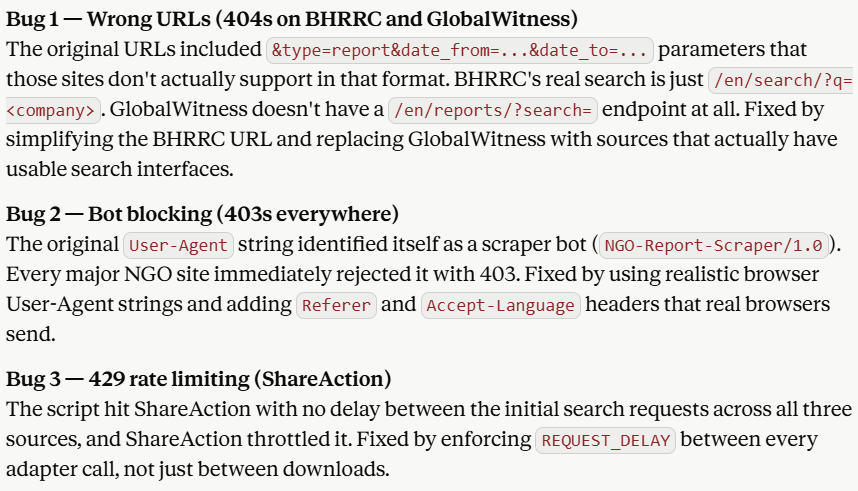

Bug 1 — Wrong URLs (404s on BHRRC and GlobalWitness)

The original URLs included &type=report&date_from=...&date_to=... parameters that those sites don't actually support in that format. BHRRC's real search is just /en/search/?q=<company>. GlobalWitness doesn't have a /en/reports/?search= endpoint at all. Fixed by simplifying the BHRRC URL and replacing GlobalWitness with sources that actually have usable search interfaces.

Bug 2 — Bot blocking (403s everywhere)

The original User-Agent string identified itself as a scraper bot (NGO-Report-Scraper/1.0). Every major NGO site immediately rejected it with 403. Fixed by using realistic browser User-Agent strings and adding Referer and Accept-Language headers that real browsers send.

Bug 3 — 429 rate limiting (ShareAction)

The script hit ShareAction with no delay between the initial search requests across all three sources, and ShareAction throttled it. Fixed by enforcing REQUEST_DELAY between every adapter call, not just between downloads.

Sources were also swapped out for ones that actually expose usable data:

WikiRate — open REST API, returns JSON with no auth
GoodJobsFirst Violation Tracker — public HTML table of corporate penalties, filterable by year
OpenSanctions — free POST API for sanctions/watchlist data
BHRRC — kept, but with corrected URL and proper headers